ModuleNotFoundError: No module named 'obspy'

In [2]:
conda install obspy

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.5.0
    latest version: 24.9.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /srv/conda/envs/notebook

  added / updated specs:
    - obspy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    attr-2.5.1                 |       h166bdaf_1          69 KB  conda-forge
    glib-2.80.3                |       h315aac3_2         585 KB  conda-forge
    glib-tools-2.80.3          |       h8fdd7da_2         112 KB  conda-forge
    gst-plugins-base-1.24.7    |       h0a52356_0         2.7 MB  conda-forge
    gstreamer-1.24.7           |       hf3bb09a_0         1.9 MB  conda-forge
    lame-3.100                 |    h166bdaf_1003         496 KB  conda-forge
    libcap-2.69   

In [3]:
import obspy
from obspy import UTCDateTime as utc
from obspy.clients.fdsn import Client
client = Client('IRIS')
import numpy as np
import os

In [4]:
def process(st, buffer, freq, max_target_frequency): #freq is the original sampling frequency
    st.merge(fill_value='interpolate')
    tr = st[0].copy()

In [7]:
#creating variables to download data
starttime = utc('2023-07-9T00:00:00')
endtime = starttime + 100 * (60*60*24)

#also add a buffer to both ends to chop off once the data has been filtered
#and downsampled, kind of arbitrary length, 5% of a day (default ObsPy taper length)
buffer = 60*60*24*0.05 #seconds

net = 'AV'
sta = 'SSLS'
loc = '*' #wildcard, generally don't care about location code
cha = 'BHN' #horizontal component, as used in Zali et al

#create folder for numpy streams to go into and initialize filepath
!mkdir data
!mkdir data/raw
filepath = os.getcwd() + '/data/raw/'

#create arrays to save dates
dates = np.array([])

print(f'Downloading data from {starttime} to {endtime}')

#download the data piecemeal, here by day
for day in range(100):
    tr_length = 24*60*60

    #actually downloading
    st = client.get_waveforms(network=net,
                     station=sta,
                     location=loc,
                     channel=cha,
                     starttime=starttime-buffer,
                     endtime=starttime+buffer+tr_length)

    #instrument sampling rate (hz)
    freq = st[0].stats.sampling_rate

    #merge traces within stream, linearly interpolating any gaps
    st.merge(fill_value='interpolate')
    
    #generate filename, day number in front for convenience of reading in
    name = str(day+1)+'_sitkin.mseed'
    
    #save data as mseed, standard for storing seismic data. Preserves metadata and time series info
    st.write(filepath+name, format='MSEED')

    #adding date
    dates = np.append(dates, starttime.date)

    starttime += tr_length

#save dates list for future use
np.save(filepath+'date_list.csv', dates)

print(f'data download complete, saved to {filepath}')

mkdir: cannot create directory ‘data’: File exists
mkdir: cannot create directory ‘data/raw’: File exists
data download complete, saved to /home/jovyan/data/raw/


In [8]:
# display some data from the mseed file
print(f'Example data from {name}')
print(st[0].stats)
print()

# display the numpy array
print(f'Example data from {name}')
print(st[0].data)
print()

Example data from 100_sitkin.mseed
               network: AV
               station: SSLS
              location: 
               channel: BHN
             starttime: 2023-10-15T22:48:00.000000Z
               endtime: 2023-10-17T01:12:00.000000Z
         sampling_rate: 50.0
                 delta: 0.02
                  npts: 4752001
                 calib: 1.0
_fdsnws_dataselect_url: http://service.iris.edu/fdsnws/dataselect/1/query
               _format: MSEED
                 mseed: AttribDict({'dataquality': 'M', 'number_of_records': 13525, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 6924800})
            processing: ['ObsPy 1.4.1: trim(endtime=UTCDateTime(2023, 10, 17, 1, 12)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2023, 10, 15, 22, 48))']

Example data from 100_sitkin.mseed
[-1221 -1358 -1385 ...   655   658   565]



In [9]:
! mkdir data/ai_ready
filepath = os.getcwd() + '/data/ai_ready/'
clean_filepath = os.getcwd() + '/data/clean/'

In [10]:
hundred_data = np.array([])

for i in range(100):
    i += 1

    #read mseed
    st = read(clean_filepath+str(i)+'_cleaned.mseed')

    #save data to day long npys
    data = st[0].data[0:-1] #removing extra point from decimating
    np.save(filepath+str(i)+'_ready.npy', data)

    #append to overall array
    hundred_data = np.append(hundred_data, data)

#save hundred day data npy
np.save(filepath+'100_days.npy', hundred_data)

NameError: name 'read' is not defined

In [12]:
hundred_data = np.array([])

for i in range(100):
    i += 1

    #read mseed
    st = read(clean_filepath+str(i)+'_cleaned.mseed')

    #save data to day long npys
    data = st[0].data[0:-1] #removing extra point from decimating
    np.save(filepath+str(i)+'_ready.npy', data)

    #append to overall array
    hundred_data = np.append(hundred_data, data)

#save hundred day data npy
np.save(filepath+'100_days.npy', hundred_data)

NameError: name 'pd' is not defined

In [13]:
import obspy
from obspy import read
import numpy as np
import os

In [10]:
! mkdir data/ai_ready
filepath = os.getcwd() + '/data/ai_ready/'
clean_filepath = os.getcwd() + '/data/clean/'

mkdir: cannot create directory ‘data/ai_ready’: File exists


In [11]:
hundred_data = np.array([])

for i in range(100):
    i += 1

    #read mseed
    st = read(clean_filepath+str(i)+'_cleaned.mseed')

    #save data to day long npys
    data = st[0].data[0:-1] #removing extra point from decimating
    np.save(filepath+str(i)+'_ready.npy', data)

    #append to overall array
    hundred_data = np.append(hundred_data, data)

#save hundred day data npy
np.save(filepath+'100_days.npy', hundred_data)

NameError: name 'read' is not defined

In [18]:
! mkdir data/ai_ready
filepath = os.getcwd() + '/data/ai_ready/'
clean_filepath = os.getcwd() + '/data/clean/'

mkdir: cannot create directory ‘data/ai_ready’: File exists


In [1]:
hundred_data = np.array([])

for i in range(100):
    i += 1

    #read mseed
    st = read(str(i)+'_sitkin.mseed')

    #save data to day long npys
    data = st[0].data[0:-1] #removing extra point from decimating
    np.save(filepath+str(i)+'_ready.npy', data)

    #append to overall array
    hundred_data = np.append(hundred_data, data)

#save hundred day data npy
np.save(filepath+'100_days.npy', hundred_data)

NameError: name 'np' is not defined

In [2]:
import obspy
from obspy import UTCDateTime as utc
from obspy.clients.fdsn import Client
client = Client('IRIS')
import numpy as np
import os

ModuleNotFoundError: No module named 'obspy'

In [3]:
import obspy

ModuleNotFoundError: No module named 'obspy'

In [4]:
conda install obspy

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.5.0
    latest version: 24.9.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /srv/conda/envs/notebook

  added / updated specs:
    - obspy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    attr-2.5.1                 |       h166bdaf_1          69 KB  conda-forge
    glib-2.80.3                |       h315aac3_2         585 KB  conda-forge
    glib-tools-2.80.3          |       h8fdd7da_2         112 KB  conda-forge
    gst-plugins-base-1.24.7    |       h0a52356_0         2.7 MB  conda-forge
    gstreamer-1.24.7           |       hf3bb09a_0         1.9 MB  conda-forge
    lame-3.100                 |    h166bdaf_1003         496 KB  conda-forge
    libcap-2.69   

In [5]:
import obspy
from obspy import UTCDateTime as utc
from obspy.clients.fdsn import Client
client = Client('IRIS')
import numpy as np
import os

In [6]:
hundred_data = np.array([])

for i in range(100):
    i += 1

    #read mseed
    st = read(str(i)+'_sitkin.mseed')

    #save data to day long npys
    data = st[0].data[0:-1] #removing extra point from decimating
    np.save(filepath+str(i)+'_ready.npy', data)

    #append to overall array
    hundred_data = np.append(hundred_data, data)

#save hundred day data npy
np.save(filepath+'100_days.npy', hundred_data)

NameError: name 'read' is not defined

In [8]:
import numpy as np

In [9]:
hundred_data = np.array([])

for i in range(100):
    i += 1

    #read mseed
    st = read(str(i)+'_sitkin.mseed')

    #save data to day long npys
    data = st[0].data[0:-1] #removing extra point from decimating
    np.save(filepath+str(i)+'_ready.npy', data)

    #append to overall array
    hundred_data = np.append(hundred_data, data)

#save hundred day data npy
np.save(filepath+'100_days.npy', hundred_data)

NameError: name 'read' is not defined

In [12]:
from obspy import read

In [13]:
hundred_data = np.array([])

for i in range(100):
    i += 1

    #read mseed
    st = read(str(i)+'_sitkin.mseed')

    #save data to day long npys
    data = st[0].data[0:-1] #removing extra point from decimating
    np.save(filepath+str(i)+'_ready.npy', data)

    #append to overall array
    hundred_data = np.append(hundred_data, data)

#save hundred day data npy
np.save(filepath+'100_days.npy', hundred_data)

FileNotFoundError: [Errno 2] No such file or directory: '1_sitkin.mseed'

In [2]:
import obspy
from obspy import read
from obspy import UTCDateTime as utc
from obspy.clients.fdsn import Client
client = Client('IRIS')

import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
! mkdir data/clean
filepath = os.getcwd() + '/data/clean/'
raw_filepath = os.getcwd() + '/data/raw/'

mkdir: cannot create directory ‘data/clean’: File exists


In [4]:
def process(st, buffer, freq, max_target_frequency): #freq is the original sampling frequency
    tr = st[0].copy()

    #demean and detrend
    tr.detrend('demean')
    tr.detrend('linear')

    #taper data (to specified taper buffer)
    tr.taper(max_percentage=0.05)

    #lowpass filter data to avoid aliasing when downsampling
    tr.filter('lowpass', freq=2*max_target_frequency, zerophase=True)

    #downsample to 20 Hz
    dec_factor = int(freq / (2*max_target_frequency))
    tr.decimate(dec_factor, no_filter=True)

    #trim off tapered edges
    tr.trim(starttime=tr.stats.starttime+buffer, endtime=tr.stats.endtime-buffer)

    return(tr)

In [ ]:
length = np.array([])

for i in range(100):
    i += 1
    mseed_name = str(i)+'_sitkin.mseed'
    st = read(raw_filepath+mseed_name)

    #parameters for processing function
    buffer = 60*60*24*0.05 #seconds
    freq = st[0].stats.sampling_rate
    max_target_freq = 10

    #do processing
    tr = process(st, buffer, freq, max_target_freq)

    #save trace to mseed again
    tr.write(filepath+str(i)+'_cleaned.mseed', format='MSEED')

    #add data length to array
    length = np.append(length, len(tr.data))

    #plot and save figures
    fig, ax = plt.subplots()
    fig.set_size_inches(6,6)
    ax.plot(tr.times('relative'), tr.data, c='k')
    ax.set_title('Data for Day '+mseed_name.split('_')[0])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Counts')
    ax.set_xlim(0, len(tr.data)/freq)
    ax.grid()
    plt.tight_layout()
    plt.savefig(filepath+'Day'+mseed_name.split('_')[0]+'.png')
    plt.close();

/srv/conda/envs/notebook/lib/python3.11/site-packages/obspy/io/mseed/core.py:773: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


In [ ]:
np.unique(length)


In [1]:
! mkdir data/ai_ready
filepath = os.getcwd() + '/data/ai_ready/'
clean_filepath = os.getcwd() + '/data/clean/'

mkdir: cannot create directory ‘data/ai_ready’: File exists


NameError: name 'os' is not defined

In [3]:
import obspy
from obspy import read
import numpy as np
import os

ModuleNotFoundError: No module named 'obspy'

In [3]:
! mkdir data/ai_ready
filepath = os.getcwd() + '/data/ai_ready/'
clean_filepath = os.getcwd() + '/data/clean/'

mkdir: cannot create directory ‘data/ai_ready’: File exists


In [5]:
hundred_data = np.array([])

for i in range(23):
    i += 1

    #read mseed
    st = read(clean_filepath+str(i)+'_cleaned.mseed')

    #save data to day long npys
    data = st[0].data[0:-1] #removing extra point from decimating
    np.save(filepath+str(i)+'_ready.npy', data)

    #append to overall array
    hundred_data = np.append(hundred_data, data)

#save hundred day data npy
np.save(filepath+'100_days.npy', hundred_data)

In [1]:
import numpy as np
import pandas as pd
import os

# Load the data from the .npy file
data_path = 'data/ai_ready'
file_name = '1_ready.npy'
full_path = os.path.join(data_path, file_name)
east_component_data = np.load(full_path)

# Define a window size and overlap (in number of samples)
freq = 25 #25 samples per second (For Sitkin Data)
window_size = 15 * 60 * 25  #15 minute long window
overlap = 500

# Sliding window function
def sliding_window(data, window_size, overlap):
    step = window_size - overlap
    windows = [data[i:i+window_size] for i in range(0, len(data)-window_size+1, step)]
    return windows

# Apply the sliding window function to the data
windows = sliding_window(east_component_data, window_size, overlap)

# Feature extraction: calculate mean, std, etc. for each window
features = []
for window in windows:
    mean = np.mean(window)
    std = np.std(window)
    max_val = np.max(window)
    min_val = np.min(window)
    features.append([mean, std, max_val, min_val])

# Convert the features list to a NumPy array
features = np.array(features)

# Print the shape of the features array to verify
print('Features shape:', features.shape, '\n')

# Print the first few rows of the features array
print('First 5 rows of features:')
print(features[:5], '\n')

# Print summary statistics for each feature
feature_names = ['Mean', 'Std', 'Max', 'Min']
for i, name in enumerate(feature_names):
    print(f'{name} - Mean: {np.mean(features[:, i]):.2f}, Std: {np.std(features[:, i]):.2f}, '
          f'Min: {np.min(features[:, i]):.2f}, Max: {np.max(features[:, i]):.2f}')

# Print the data types of the features
print('Data types of features:', features.dtype)

# Optionally, save the features to a new .npy file
output_file = os.path.join(data_path, '1_ready_features.npy')
#os.makedirs(data_path, exist_ok=True)
np.save(output_file, features)

Features shape: (98, 4) 

First 5 rows of features:
[[ 1.02876323e+01  7.67438691e+02  2.92081630e+03 -2.65583314e+03]
 [ 2.01107103e+00  7.94315758e+02  2.94481316e+03 -3.52310441e+03]
 [ 2.46257613e+01  7.21556154e+02  3.15327550e+03 -2.68478806e+03]
 [ 1.25693991e+01  7.41027306e+02  2.83721236e+03 -2.48450586e+03]
 [ 2.69797553e+01  7.59949501e+02  3.05015291e+03 -3.10917569e+03]] 

Mean - Mean: -0.99, Std: 28.26, Min: -60.00, Max: 43.67
Std - Mean: 705.57, Std: 109.98, Min: 472.28, Max: 879.07
Max - Mean: 2988.41, Std: 532.99, Min: 2021.81, Max: 5361.26
Min - Mean: -2987.16, Std: 578.50, Min: -5160.68, Max: -1973.58
Data types of features: float64


In [2]:
#put features into labeled dataframe
stats_df = pd.DataFrame(features, columns=['Mean', 'Std', 'Max', 'Min'])

#calculation correlation matrix
corr_matrix = stats_df.corr()

#display correlation matrix
plt.title('Correlation Matrix')
plt.pcolor(corr_matrix, cmap='PuOr_r')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns);

NameError: name 'plt' is not defined

In [4]:
conda install obspy

Retrieving notices: ...working... done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.5.0
    latest version: 24.9.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /srv/conda/envs/notebook

  added / updated specs:
    - obspy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    attr-2.5.1                 |       h166bdaf_1          69 KB  conda-forge
    glib-2.80.3                |       h315aac3_2         585 KB  conda-forge
    glib-tools-2.80.3          |       h8fdd7da_2         112 KB  conda-forge
    gst-plugins-base-1.24.7    |       h0a52356_0         2.7 MB  conda-forge
    gstreamer-1.24.7           |       hf3bb09a_0         1.9 MB  conda-forge
    lame-3.100                 |    h166bdaf_1003        

In [5]:
import obspy
from obspy import read
import numpy as np
import os

In [6]:
#put features into labeled dataframe
stats_df = pd.DataFrame(features, columns=['Mean', 'Std', 'Max', 'Min'])

#calculation correlation matrix
corr_matrix = stats_df.corr()

#display correlation matrix
plt.title('Correlation Matrix')
plt.pcolor(corr_matrix, cmap='PuOr_r')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns);

NameError: name 'plt' is not defined

In [7]:
from matplotlib import pyplot as plt

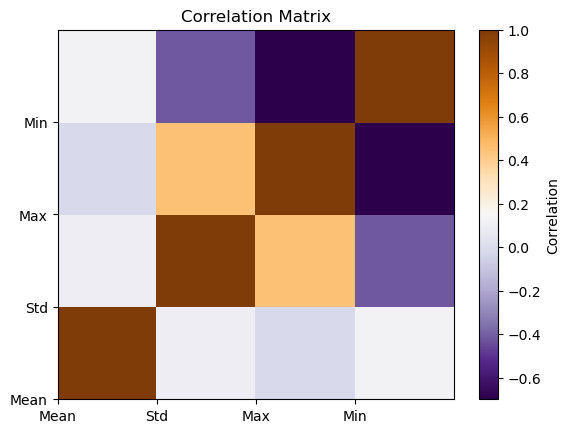

In [8]:
#put features into labeled dataframe
stats_df = pd.DataFrame(features, columns=['Mean', 'Std', 'Max', 'Min'])

#calculation correlation matrix
corr_matrix = stats_df.corr()

#display correlation matrix
plt.title('Correlation Matrix')
plt.pcolor(corr_matrix, cmap='PuOr_r')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns);